# Office Supply and Demand Analysis

This notebook compares demand drivers and office inventory to frame market balance in the Clarkston PMA.

**Workflow:** load market datasets, calculate key ratios, and produce supporting tables.


In [1]:
import pandas as pd

df_comps = pd.read_excel('../data/Office/Comps_office_retail_MF_within8m.xlsx')
df_off_ret = pd.read_excel('../data/Office/Market_office_retail_within8miles.xlsx')
df_office = pd.read_excel('../data/Office/Market_office_within8m.xlsx')

In [2]:
# Read in Market A office/retail and office datasets (note: 'A office')
df_A_off_ret = pd.read_excel('../data/Office/Market_A_office_retail_within8miles.xlsx')
df_A_office = pd.read_excel('../data/Office/Market_A_office_within8m.xlsx')

In [3]:
import pandas as pd

# Clean column names (remove leading/trailing spaces)
for df in [df_A_office, df_off_ret, df_comps, df_office, df_A_off_ret]:
    if hasattr(df, "columns"):
        df.columns = df.columns.str.strip()

# Normalize 'Period' column (extract year)
for df in [df_A_office, df_A_off_ret, df_office, df_off_ret, df_comps]:
    if 'Period' in df.columns:
        df['Period'] = (
            df['Period']
            .astype(str)
            .str.extract(r"(\d{4})")
            .iloc[:, 0]
            .astype("Int64")
        )

# Ensure vacancy column is numeric
for df in [df_A_office, df_A_off_ret, df_office, df_off_ret, df_comps]:
    if 'Vacant Percent % Total' in df.columns:
        df['Vacant Percent % Total'] = pd.to_numeric(df['Vacant Percent % Total'], errors='coerce')

# Compute and print long-run average and 2025 average for each dataset
datasets = {
    "A_office": df_A_office,
    "A_office_retail": df_A_off_ret,
    "office": df_office,
    "office_retail": df_off_ret,
    "comps": df_comps
}

for name, df in datasets.items():
    if 'Vacant Percent % Total' in df.columns:
        overall_avg = df['Vacant Percent % Total'].mean()
        latest_year = 2025
        if 'Period' in df.columns:
            avg_latest = df.loc[df['Period'] == latest_year, 'Vacant Percent % Total'].mean()
            print(f"{name}:")
            print(f"  Average vacancy (all data): {overall_avg:.2f}")
            if pd.isna(avg_latest) or not df['Period'].eq(latest_year).any():
                print(f"  Vacancy for {latest_year}: No data for {latest_year}")
            else:
                print(f"  Vacancy for {latest_year}: {avg_latest:.2f}")
            print()
        else:
            print(f"{name}: No 'Period' column, cannot compute {latest_year} vacancy.\n")
    else:
        print(f"{name}: 'Vacant Percent % Total' column not present, skipping.\n")

A_office:
  Average vacancy (all data): 0.16
  Vacancy for 2025: 0.28

A_office_retail:
  Average vacancy (all data): 0.16
  Vacancy for 2025: 0.28

office:
  Average vacancy (all data): 0.17
  Vacancy for 2025: 0.28

office_retail:
  Average vacancy (all data): 0.17
  Vacancy for 2025: 0.28

comps:
  Average vacancy (all data): 0.20
  Vacancy for 2025: No data for 2025



In [4]:
df_office.head()

,Period,Inventory Bldgs,Inventory SF,Vacant SF Direct,Vacant SF Sublet,Vacant SF Total,Vacant Percent % Direct,Vacant Percent % Sublet,Vacant Percent % Total,Total Available SF Direct,...,Deliveries Bldgs,Deliveries SF,Under Construction Bldgs,Under Construction SF,Office Gross Rent Direct,Office Gross Rent Sublet,Office Gross Rent Overall,Office Base Rent Direct,Office Base Rent Sublet,Office Base Rent Overall
0,2026,272,22054064,6165256,255270,6420526,0.280,0.012,0.291,6625234,...,2,25195,-,-,37.06,23.39,36.78,34.21,21.4,33.92
1,2025,270,22028869,5902292,241113,6143405,0.268,0.011,0.279,6399391,...,-,-,2,25195,36.95,24.69,36.54,33.78,23.87,33.44
2,2024,270,22028869,5535547,194527,5730074,0.251,0.009,0.260,6254777,...,-,-,2,25195,35.10,23.41,34.69,32.74,22.82,32.40
3,2023,270,22028869,5626616,265437,5892053,0.255,0.012,0.267,5857188,...,-,-,2,25195,35.51,23.45,35.10,33.19,22.96,32.83
4,2022,270,22028869,4599044,205397,4804441,0.209,0.009,0.218,5432851,...,4,1178274,-,-,35.09,22.51,34.38,33.17,21.73,32.52


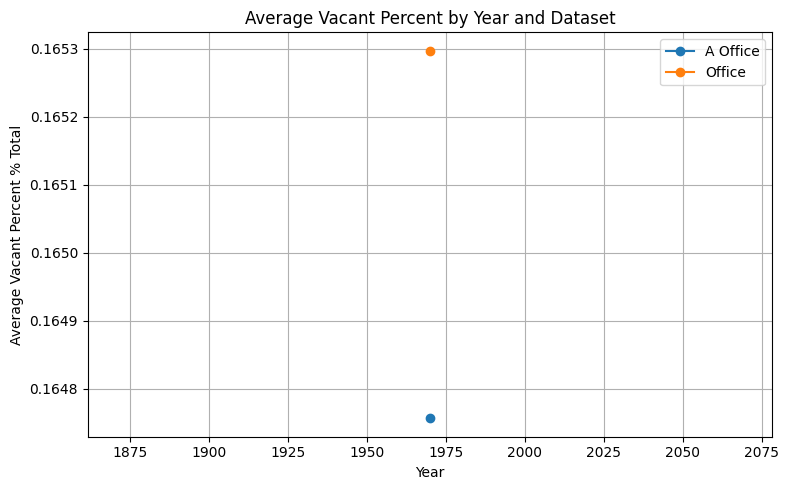

In [5]:
import matplotlib.pyplot as plt

# Remove spaces in column names (strip whitespace)
df_A_office.columns = df_A_office.columns.str.strip()
df_office.columns = df_office.columns.str.strip()

# Convert Period column to datetime or numeric, if necessary
df_A_office['Period'] = pd.to_datetime(df_A_office['Period'], errors='coerce').dt.year
df_office['Period'] = pd.to_datetime(df_office['Period'], errors='coerce').dt.year

# Group by Period and get average vacant percent for each dataset by year
avg_vacant_A_office = df_A_office.groupby('Period')['Vacant Percent % Total'].mean().reset_index()
avg_vacant_office = df_office.groupby('Period')['Vacant Percent % Total'].mean().reset_index()

# Prepare the plot
plt.figure(figsize=(8, 5))
plt.plot(avg_vacant_A_office['Period'], avg_vacant_A_office['Vacant Percent % Total'],
         marker='o', label='A Office')
plt.plot(avg_vacant_office['Period'], avg_vacant_office['Vacant Percent % Total'],
         marker='o', label='Office')

plt.title("Average Vacant Percent by Year and Dataset")
plt.xlabel("Year")
plt.ylabel("Average Vacant Percent % Total")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
with pd.option_context('display.max_columns', None):
    display(df_office.head())

,Period,Inventory Bldgs,Inventory SF,Vacant SF Direct,Vacant SF Sublet,Vacant SF Total,Vacant Percent % Direct,Vacant Percent % Sublet,Vacant Percent % Total,Total Available SF Direct,Total Available SF Sublet,Total Available SF Total,Total Available Percent % Direct,Total Available Percent % Sublet,Total Available Percent % Total,Vacant Available SF Direct,Vacant Available SF Sublet,Vacant Available SF Total,Vacant Available Percent % Direct,Vacant Available Percent % Sublet,Vacant Available Percent % Total,Occupancy SF,Occupancy Percent,Net Absorption SF Direct,Net Absorption SF Sublet,Net Absorption SF Total,Gross Absorption SF Direct,Gross Absorption SF Sublet,Gross Absorption SF Total,Leasing Activity Deals Direct,Leasing Activity Deals Sublet,Leasing Activity Deals Total,Leasing Activity SF Direct,Leasing Activity SF Sublet,Leasing Activity SF Total,Deliveries Bldgs,Deliveries SF,Under Construction Bldgs,Under Construction SF,Office Gross Rent Direct,Office Gross Rent Sublet,Office Gross Rent Overall,Office Base Rent Direct,Office Base Rent Sublet,Office Base Rent Overall
0,1970,272,22054064,6165256,255270,6420526,0.280,0.012,0.291,6625234,515760,7127219,0.3,0.023,0.323,5862926,251200,6114126,0.266,0.011,0.277,15633538,0.709,-239969,-14157,-254126,274527,43900,318427,64,12,76,171852,29721,201573,2,25195,-,-,37.06,23.39,36.78,34.21,21.4,33.92
1,1970,270,22028869,5902292,241113,6143405,0.268,0.011,0.279,6399391,550675,6936291,0.29,0.025,0.315,5610286,241113,5851399,0.255,0.011,0.266,15885464,0.721,-366745,-46586,-413331,1662293,158173,1820466,278,25,303,1319504,121769,1441273,-,-,2,25195,36.95,24.69,36.54,33.78,23.87,33.44
2,1970,270,22028869,5535547,194527,5730074,0.251,0.009,0.260,6254777,514529,6769306,0.284,0.023,0.307,5002493,194527,5197020,0.227,0.009,0.236,16298795,0.740,91069,70910,161979,1897505,327341,2224846,277,27,304,1569618,111430,1681048,-,-,2,25195,35.10,23.41,34.69,32.74,22.82,32.40
3,1970,270,22028869,5626616,265437,5892053,0.255,0.012,0.267,5857188,504559,6361747,0.266,0.023,0.288,4824270,265437,5089707,0.219,0.012,0.231,16136816,0.733,-1027572,-60040,-1087612,1417899,266182,1684081,289,26,315,1601300,87233,1688533,-,-,2,25195,35.51,23.45,35.10,33.19,22.96,32.83
4,1970,270,22028869,4599044,205397,4804441,0.209,0.009,0.218,5432851,637256,6070107,0.247,0.029,0.276,3909605,205397,4115002,0.177,0.009,0.187,17224428,0.782,340155,3463,343618,2155933,235048,2390981,286,10,296,1060875,20933,1081808,4,1178274,-,-,35.09,22.51,34.38,33.17,21.73,32.52


In [7]:
df_A_office.head()

,Period,Inventory Bldgs,Inventory SF,Vacant SF Direct,Vacant SF Sublet,Vacant SF Total,Vacant Percent % Direct,Vacant Percent % Sublet,Vacant Percent % Total,Total Available SF Direct,...,Deliveries Bldgs,Deliveries SF,Under Construction Bldgs,Under Construction SF,Office Gross Rent Direct,Office Gross Rent Sublet,Office Gross Rent Overall,Office Base Rent Direct,Office Base Rent Sublet,Office Base Rent Overall
0,1970,48,14830777,4110918,189865,4300783,0.277,0.013,0.290,4324100,...,-,-,-,-,40.79,25.45,40.55,37.74,23.78,37.49
1,1970,48,14830777,3954751,167602,4122353,0.267,0.011,0.278,4279251,...,-,-,-,-,41.67,26.73,41.25,38.04,26.73,37.72
2,1970,48,14830777,4077357,134611,4211968,0.275,0.009,0.284,4369211,...,-,-,-,-,39.02,25.77,38.69,36.33,25.77,36.07
3,1970,48,14830777,4188687,226522,4415209,0.282,0.015,0.298,4153984,...,-,-,-,-,39.48,23.97,38.82,36.82,23.97,36.28
4,1970,48,14830777,3308967,158739,3467706,0.223,0.011,0.234,3856661,...,3,1146071,-,-,38.97,22.27,37.76,36.57,21.85,35.51


In [8]:
import pandas as pd

# 1. Setup and Data Cleaning Helper
def clean_office_data(df):
    """Cleans numeric columns and strips whitespace from column names, including 'Period' handling."""
    # Strip column names
    df.columns = df.columns.str.strip()
    
    cols_to_fix = [
        'Net Absorption SF Total', 
        'Total Available SF Total', 
        'Inventory SF'
    ]
    
    for col in cols_to_fix:
        if col in df.columns:
            df[col] = (df[col].astype(str)
                       .str.replace(',', '')
                       .replace('-', '0')
                       .astype(float))
    return df

# Clean both dataframes (make sure column names are stripped)
df_A_office = clean_office_data(df_A_office)
df_office = clean_office_data(df_office)

# Fix possible "Period" column mismatches (e.g., leading/trailing spaces, or numeric type)
# Get the exact matching column name for 'Period', case-insensitively, with possible whitespace
def get_period_col(cols):
    # Find the 'Period' column regardless of whitespace/case
    for c in cols:
        if c.strip().lower() == 'period':
            return c
    raise KeyError("No 'Period' column found!")

period_col_A = get_period_col(df_A_office.columns)
period_col_all = get_period_col(df_office.columns)

# Ensure 'Period' is string for .str ops; fallback to astype(str) safely
df_A_office[period_col_A] = df_A_office[period_col_A].astype(str).str.strip()
df_office[period_col_all] = df_office[period_col_all].astype(str).str.strip()

# Identify full years (excluding YTD partial years)
full_years_A = df_A_office[df_A_office[period_col_A].str.match(r'^\d{4}$')].sort_values(period_col_A, ascending=False)
full_years_all = df_office[df_office[period_col_all].str.match(r'^\d{4}$')].sort_values(period_col_all, ascending=False)

# Calculate Class A Absorption Rates
recent_abs_A = full_years_A.head(3)['Net Absorption SF Total'].mean()  # 3-Year Recent
long_run_abs_A = full_years_A['Net Absorption SF Total'].mean()        # Long Run (all available years)

# Calculate All Office Absorption Rates
recent_abs_all = full_years_all.head(3)['Net Absorption SF Total'].mean()
long_run_abs_all = full_years_all['Net Absorption SF Total'].mean()    # Long Run (all available years)

# Current Availability (Starting Point 2026)
current_avail_A = df_A_office.iloc[0]['Total Available SF Total']
current_avail_all = df_office.iloc[0]['Total Available SF Total']

# 3. 2029 Projections
years_to_delivery = 3

proj_2029_A_recent = current_avail_A - (recent_abs_A * years_to_delivery)
proj_2029_A_long = current_avail_A - (long_run_abs_A * years_to_delivery)

proj_2029_all_recent = current_avail_all - (recent_abs_all * years_to_delivery)
proj_2029_all_long = current_avail_all - (long_run_abs_all * years_to_delivery)

# 4. Display Results
print("--- CLASS A OFFICE ANALYSIS ---")
print(f"Recent Absorption (3-yr avg): {recent_abs_A:,.0f} SF/year")
print(f"Long-Run Absorption (all available years avg): {long_run_abs_A:,.0f} SF/year")
print(f"Projected 2029 Availability (Recent Trend): {proj_2029_A_recent:,.0f} SF")
print(f"Projected 2029 Availability (Long-Run Trend): {proj_2029_A_long:,.0f} SF")

print("\n--- ALL OFFICE ANALYSIS ---")
print(f"Recent Absorption (3-yr avg): {recent_abs_all:,.0f} SF/year")
print(f"Long-Run Absorption (all available years avg): {long_run_abs_all:,.0f} SF/year")
print(f"Projected 2029 Availability (Recent Trend): {proj_2029_all_recent:,.0f} SF")
print(f"Projected 2029 Availability (Long-Run Trend): {proj_2029_all_long:,.0f} SF")

--- CLASS A OFFICE ANALYSIS ---
Recent Absorption (3-yr avg): 55,271 SF/year
Long-Run Absorption (all available years avg): 156,922 SF/year
Projected 2029 Availability (Recent Trend): 4,513,795 SF
Projected 2029 Availability (Long-Run Trend): 4,208,840 SF

--- ALL OFFICE ANALYSIS ---
Recent Absorption (3-yr avg): 35,947 SF/year
Long-Run Absorption (all available years avg): 160,544 SF/year
Projected 2029 Availability (Recent Trend): 7,019,378 SF
Projected 2029 Availability (Long-Run Trend): 6,645,586 SF
